# CAPSTONE PROJECT PBI RAKAMIN X ID/X PARTNERS

In [146]:
# from google.colab import drive
# drive.mount('/content/drive')

## IMPORT LIBRARIES

In [147]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import math
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix
from sklearn.metrics import accuracy_score,classification_report
from sklearn.metrics import roc_auc_score
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC

In [148]:
pd.set_option('display.max_columns', None)

## LOAD DATA

In [149]:
#@title Load Dataset
df = pd.read_csv('loan_data_2007_2014.csv')

C:\Users\HP\AppData\Local\Temp\ipykernel_22804\3353639200.py:2: DtypeWarning: Columns (20) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv('loan_data_2007_2014.csv')


In [150]:
#@title Showing Head of Dataset
df.head()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_title,emp_length,home_ownership,annual_inc,verification_status,issue_d,loan_status,pymnt_plan,url,desc,purpose,title,zip_code,addr_state,dti,delinq_2yrs,earliest_cr_line,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_d,last_pymnt_amnt,next_pymnt_d,last_credit_pull_d,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,application_type,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
0,0,1077501,1296599,5000,5000,4975.0,36 months,10.65,162.87,B,B2,NaN,10+ years,RENT,24000.0,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I need to upgra...,credit_card,Computer,860xx,AZ,27.65,0.0,Jan-85,1.0,NaN,NaN,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,Jan-15,171.62,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,1,1077430,1314167,2500,2500,2500.0,60 months,15.27,59.83,C,C4,Ryder,< 1 year,RENT,30000.0,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/22/11 > I plan to use t...,car,bike,309xx,GA,1.00,0.0,Apr-99,5.0,NaN,NaN,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,Apr-13,119.66,NaN,Sep-13,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2,1077175,1313524,2400,2400,2400.0,36 months,15.96,84.33,C,C5,NaN,10+ years,RENT,12252.0,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,NaN,small_business,real estate business,606xx,IL,8.72,0.0,Nov-01,2.0,NaN,NaN,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,Jun-14,649.91,NaN,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3,1076863,1277178,10000,10000,10000.0,36 months,13.49,339.31,C,C1,AIR RESOURCES BOARD,10+ years,RENT,49200.0,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > to pay for prop...,other,personel,917xx,CA,20.00,0.0,Feb-96,1.0,35.0,NaN,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,Jan-15,357.48,NaN,Jan-15,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,4,1075358,1311748,3000,3000,3000.0,60 months,12.69,67.79,B,B5,University Medical Group,1 year,RENT,80000.0,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,Borrower added on 12/21/11 > I plan on combi...,other,Personal,972xx,OR,17.94,0.0,Jan-96,0.0,38.0,NaN,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,Jan-16,67.79,Feb-16,Jan-16,0.0,NaN,1,INDIVIDUAL,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## DATA UNDERSTANDING

In [151]:
#@title Information of Dataset
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 466285 entries, 0 to 466284
Data columns (total 75 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   Unnamed: 0                   466285 non-null  int64  
 1   id                           466285 non-null  int64  
 2   member_id                    466285 non-null  int64  
 3   loan_amnt                    466285 non-null  int64  
 4   funded_amnt                  466285 non-null  int64  
 5   funded_amnt_inv              466285 non-null  float64
 6   term                         466285 non-null  object 
 7   int_rate                     466285 non-null  float64
 8   installment                  466285 non-null  float64
 9   grade                        466285 non-null  object 
 10  sub_grade                    466285 non-null  object 
 11  emp_title                    438697 non-null  object 
 12  emp_length                   445277 non-null  object 
 13 

Dataset terdiri dari 466285 baris dan 75 kolom


Fitur - Fitur :

*   **🧾 Loan Information**
| Feature | Short Desc | Full Desc |
|--------|-----------|----------|
| loan_amnt | Jumlah pinjaman | Total pinjaman yang diajukan peminjam |
| funded_amnt | Dana disetujui | Total dana pinjaman yang disetujui |
| term | Durasi pinjaman | Lama pinjaman (36 atau 60 bulan) |
| int_rate | Bunga | Tingkat bunga pinjaman |
| installment | Cicilan | Pembayaran bulanan |
| loan_status | Status | Status terkini pinjaman |
| purpose | Tujuan | Tujuan penggunaan pinjaman |
| title | Judul | Judul/deskripsi singkat pinjaman |
| issue_d | Tanggal cair | Bulan pencairan pinjaman |

*   **👤 Borrower Information**
| Feature | Short Desc | Full Desc |
|--------|-----------|----------|
| annual_inc | Pendapatan | Pendapatan tahunan peminjam |
| annual_inc_joint | Pendapatan gabungan | Pendapatan tahunan joint |
| emp_length | Lama kerja | Lama kerja (0–10 tahun) |
| emp_title | Pekerjaan | Jabatan peminjam |
| home_ownership | Status rumah | Status kepemilikan rumah |
| addr_state | Lokasi | Negara bagian peminjam |
| zip_code | Kode pos | 3 digit awal kode pos |
| application_type | Tipe aplikasi | Individual / joint |

*   **💳 Credit & Risk Profile**
| Feature | Short Desc | Full Desc |
|--------|-----------|----------|
| fico_range_low | FICO min | Batas bawah skor FICO |
| fico_range_high | FICO max | Batas atas skor FICO |
| last_fico_range_low | FICO terakhir min | Skor FICO terakhir (bawah) |
| last_fico_range_high | FICO terakhir max | Skor FICO terakhir (atas) |
| dti_joint | DTI joint | Rasio utang terhadap income joint |
| Femp | DTI individu | Rasio utang terhadap income individu |
| delinq_2yrs | Delinq 2 thn | Keterlambatan >30 hari |
| acc_now_delinq | Delinq aktif | Rekening telat saat ini |
| pub_rec | Catatan publik | Catatan kredit negatif |

*   **🏦 Credit Behavior**
| Feature | Short Desc | Full Desc |
|--------|-----------|----------|
| revol_bal | Saldo revolving | Total saldo kredit bergulir |
| revol_util | Utilisasi kredit | Rasio penggunaan kredit |
| all_util | Utilisasi total | Rasio semua kredit |
| open_acc | Akun aktif | Jumlah akun kredit aktif |
| total_acc | Total akun | Total akun kredit |
| earliest_cr_line | Kredit pertama | Awal riwayat kredit |
| inq_last_6mths | Inquiry 6 bln | Cek kredit 6 bulan |
| inq_last_12m | Inquiry 12 bln | Cek kredit 12 bulan |


*   **💰 Payment & Performance**
| Feature | Short Desc | Full Desc |
|--------|-----------|----------|
| total_pymnt | Total bayar | Total pembayaran diterima |
| total_pymnt_inv | Bayar investor | Pembayaran ke investor |
| total_rec_prncp | Pokok diterima | Pokok yang sudah dibayar |
| total_rec_int | Bunga diterima | Total bunga diterima |
| total_rec_late_fee | Denda | Biaya keterlambatan |
| last_pymnt_amnt | Bayar terakhir | Jumlah pembayaran terakhir |
| last_pymnt_d | Tanggal bayar | Tanggal pembayaran terakhir |
| next_pymnt_d | Bayar berikutnya | Jadwal pembayaran berikutnya |

*   **⚠️ Collections & Recovery**
| Feature | Short Desc | Full Desc |
|--------|-----------|----------|
| recoveries | Recovery | Dana yang berhasil dipulihkan |
| collection_recovery_fee | Fee recovery | Biaya penagihan |
| collections_12_mths_ex_med | Koleksi 12 bln | Penagihan selain medis |
| mths_since_last_delinq | Bulan sejak telat | Waktu sejak keterlambatan |
| mths_since_last_record | Bulan sejak record | Waktu sejak catatan publik |

In [152]:
#@title Statistic Description of Data
df.describe()

,Unnamed: 0,id,member_id,loan_amnt,funded_amnt,funded_amnt_inv,int_rate,installment,annual_inc,dti,delinq_2yrs,inq_last_6mths,mths_since_last_delinq,mths_since_last_record,open_acc,pub_rec,revol_bal,revol_util,total_acc,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,mths_since_last_major_derog,policy_code,annual_inc_joint,dti_joint,verification_status_joint,acc_now_delinq,tot_coll_amt,tot_cur_bal,open_acc_6m,open_il_6m,open_il_12m,open_il_24m,mths_since_rcnt_il,total_bal_il,il_util,open_rv_12m,open_rv_24m,max_bal_bc,all_util,total_rev_hi_lim,inq_fi,total_cu_tl,inq_last_12m
count,466285.000000,4.662850e+05,4.662850e+05,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,4.662810e+05,466285.000000,466256.000000,466256.000000,215934.000000,62638.000000,466256.000000,466256.000000,4.662850e+05,465945.000000,466256.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466285.000000,466140.000000,98974.000000,466285.0,0.0,0.0,0.0,466256.000000,3.960090e+05,3.960090e+05,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,3.960090e+05,0.0,0.0,0.0
mean,233142.000000,1.307973e+07,1.459766e+07,14317.277577,14291.801044,14222.329888,13.829236,432.061201,7.327738e+04,17.218758,0.284678,0.804745,34.104430,74.306012,11.187069,0.160564,1.623020e+04,56.176947,25.064430,4410.062342,4408.452258,11540.686220,11469.892747,8866.014657,2588.677225,0.650129,85.344211,8.961534,3123.913796,0.009085,42.852547,1.0,NaN,NaN,NaN,0.004002,1.919135e+02,1.388017e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.037909e+04,NaN,NaN,NaN
std,134605.029472,1.089371e+07,1.168237e+07,8286.509164,8274.371300,8297.637788,4.357587,243.485550,5.496357e+04,7.851121,0.797365,1.091598,21.778487,30.357653,4.987526,0.510863,2.067625e+04,23.732628,11.600141,6355.078769,6353.198001,8265.627112,8254.157579,7031.687997,2483.809661,5.265730,552.216084,85.491437,5554.737393,0.108648,21.662591,0.0,NaN,NaN,NaN,0.068637,1.463021e+04,1.521147e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3.724713e+04,NaN,NaN,NaN
min,0.000000,5.473400e+04,7.047300e+04,500.000000,500.000000,0.000000,5.420000,15.670000,1.896000e+03,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,0.000000e+00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.000000e+00,NaN,NaN,NaN
25%,116571.000000,3.639987e+06,4.379705e+06,8000.000000,8000.000000,8000.000000,10.990000,256.690000,4.500000e+04,11.360000,0.000000,0.000000,16.000000,53.000000,8.000000,0.000000,6.413000e+03,39.200000,17.000000,0.000000,0.000000,5552.125349,5499.250000,3708.560000,957.280000,0.000000,0.000000,0.000000,312.620000,0.000000,26.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.861800e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.350000e+04,NaN,NaN,NaN
50%,233142.000000,1.010790e+07,1.194108e+07,12000.000000,12000.000000,12000.000000,13.660000,379.890000,6.300000e+04,16.870000,0.000000,0.000000,31.000000,76.000000,10.000000,0.000000,1.176400e+04,57.600000,23.000000,441.470000,441.380000,9419.250943,9355.430000,6817.760000,1818.880000,0.000000,0.000000,0.000000,545.960000,0.000000,42.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,8.153900e+04,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.280000e+04,NaN,NaN,NaN
75%,349713.000000,2.073121e+07,2.300154e+07,20000.000000,20000.000000,19950.000000,16.490000,566.580000,8.896000e+04,22.780000,0.000000,1.000000,49.000000,102.000000,14.000000,0.000000,2.033300e+04,74.700000,32.000000,7341.650000,7338.390000,15308.158460,15231.310000,12000.000000,3304.530000,0.000000,0.000000,0.000000,3187.510000,0.000000,59.000000,1.0,NaN,NaN,NaN,0.000000,0.000000e+00,2.089530e+05,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,

**1. Karakteristik Umum Data**

- Dataset terdiri dari **466.285 observasi (data pinjaman)**.
- Kolom **`Unnamed: 0`** hanya merupakan nomor urut data
- Kolom **`id`** dan **`member_id`**:
  - Berfungsi sebagai identifier unik.
  - Tidak memiliki nilai prediktif → **tidak relevan untuk modeling**.

---

**2. Karakteristik Pinjaman (Loan Characteristics)**

- **Jumlah Pinjaman (`loan_amnt`)**:
  - Rata-rata: \$14.317
  - Rentang: \$500 – \$35.000
  - Distribusi:
    - 25%: \$8.000
    - Median: \$12.000
    - 75%: \$20.000  
  👉 Mayoritas pinjaman berada pada kategori menengah.

- **Dana Disetujui (`funded_amnt`, `funded_amnt_inv`)**:
  - Nilai hampir sama dengan `loan_amnt`  
  👉 Menunjukkan bahwa sebagian besar pinjaman **didanai penuh**.

- **Suku Bunga (`int_rate`)**:
  - Rata-rata: 13.83%
  - Rentang: 5.42% – 26.06%  
  👉 Variasi tinggi mencerminkan **perbedaan risiko borrower**.

- **Cicilan Bulanan (`installment`)**:
  - Rata-rata: \$432
  - Rentang: \$15.67 – \$1.409  
  👉 Dipengaruhi oleh jumlah pinjaman dan suku bunga.

---

**3. Profil Finansial Peminjam (Borrower Financial Profile)**

- **Pendapatan Tahunan (`annual_inc`)**:
  - Rata-rata: \$73.277
  - Median: \$63.000
  - Rentang: \$1.896 – \$7.500.000  
  👉 Terdapat **outlier ekstrem**, perlu penanganan khusus.

- **Debt-to-Income Ratio (`dti`)**:
  - Rata-rata: 17.22
  - Rentang: 0 – 39.99  
  👉 Sebagian besar borrower berada pada tingkat utang moderat.

---

**4. Kapasitas Kredit**

- **Total Limit Kredit (`total_rev_hi_lim`)**:
  - Rata-rata: \$30.379
  - Median: \$22.800
  - Rentang: 0 – hampir \$10 juta  
  👉 Variasi sangat besar menunjukkan perbedaan kapasitas kredit.

---

**5. Distribusi dan Variasi Data**

- Beberapa fitur menunjukkan distribusi **tidak normal (skewed)**:
  - `annual_inc`
  - `total_rev_hi_lim`

- Ciri-ciri:
  - Mean > median
  - Nilai maksimum sangat tinggi  

👉 Mengindikasikan:
- Adanya **outlier signifikan**
- Perlu:
  - Transformasi log
  - Outlier treatment

---

**6. Missing Values (Data Kosong)**

Beberapa kolom memiliki **count = 0 (seluruh data kosong)**:
- `total_bal_il`
- `il_util`
- `open_rv_12m`
- `open_rv_24m`
- `max_bal_bc`
- `all_util`
- `inq_fi`
- `total_cu_tl`
- `inq_last_12m`

👉 Implikasi:
- Kolom tidak memiliki informasi
- Sebaiknya **dihapus dari dataset**

---

 **7. Kesimpulan Umum**

- Mayoritas pinjaman berada di kisaran **\$8.000 – \$20.000**
- Borrower umumnya memiliki **pendapatan menengah**
- Tingkat bunga bervariasi sesuai profil risiko
- Terdapat beberapa kolom dengan **data kosong total**

In [153]:
#@title Check for missing values
missing_values = df.isnull().sum()
percentage_missing = (missing_values / len(df)) * 100
missing_info = pd.DataFrame({'Missing Count': missing_values, 'Percentage': percentage_missing})
print(missing_info[missing_info['Missing Count'] > 0].sort_values(by='Missing Count', ascending=False))

                             Missing Count  Percentage
dti_joint                           466285  100.000000
annual_inc_joint                    466285  100.000000
total_cu_tl                         466285  100.000000
inq_fi                              466285  100.000000
all_util                            466285  100.000000
max_bal_bc                          466285  100.000000
open_rv_24m                         466285  100.000000
open_rv_12m                         466285  100.000000
il_util                             466285  100.000000
total_bal_il                        466285  100.000000
mths_since_rcnt_il                  466285  100.000000
open_il_24m                         466285  100.000000
open_il_12m                         466285  100.000000
open_il_6m                          466285  100.000000
open_acc_6m                         466285  100.000000
verification_status_joint           466285  100.000000
inq_last_12m                        466285  100.000000
mths_since

In [154]:
#@title Drop columns with >30% missing values

# Hitung persentase missing
missing_percentage = df.isnull().mean() * 100

# Pilih kolom dengan missing > 30%
cols_to_drop = missing_percentage[missing_percentage > 30].index

# Drop kolom
df = df.drop(columns=cols_to_drop)

# Cek hasil
print(f"Jumlah kolom yang dihapus: {len(cols_to_drop)}")
print("Kolom yang dihapus:")
print(cols_to_drop)

Jumlah kolom yang dihapus: 22
Kolom yang dihapus:
Index(['desc', 'mths_since_last_delinq', 'mths_since_last_record',
       'next_pymnt_d', 'mths_since_last_major_derog', 'annual_inc_joint',
       'dti_joint', 'verification_status_joint', 'open_acc_6m', 'open_il_6m',
       'open_il_12m', 'open_il_24m', 'mths_since_rcnt_il', 'total_bal_il',
       'il_util', 'open_rv_12m', 'open_rv_24m', 'max_bal_bc', 'all_util',
       'inq_fi', 'total_cu_tl', 'inq_last_12m'],
      dtype='object')


In [155]:
#@title Remaining Columns After Dropping >30% Missing

# Lihat semua kolom yang tersisa
remaining_cols = df.columns.tolist()

print(f"Jumlah kolom tersisa: {len(remaining_cols)}")
print("Daftar kolom:")
print(remaining_cols)

Jumlah kolom tersisa: 53
Daftar kolom:
['Unnamed: 0', 'id', 'member_id', 'loan_amnt', 'funded_amnt', 'funded_amnt_inv', 'term', 'int_rate', 'installment', 'grade', 'sub_grade', 'emp_title', 'emp_length', 'home_ownership', 'annual_inc', 'verification_status', 'issue_d', 'loan_status', 'pymnt_plan', 'url', 'purpose', 'title', 'zip_code', 'addr_state', 'dti', 'delinq_2yrs', 'earliest_cr_line', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'initial_list_status', 'out_prncp', 'out_prncp_inv', 'total_pymnt', 'total_pymnt_inv', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee', 'recoveries', 'collection_recovery_fee', 'last_pymnt_d', 'last_pymnt_amnt', 'last_credit_pull_d', 'collections_12_mths_ex_med', 'policy_code', 'application_type', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim']


## EDA

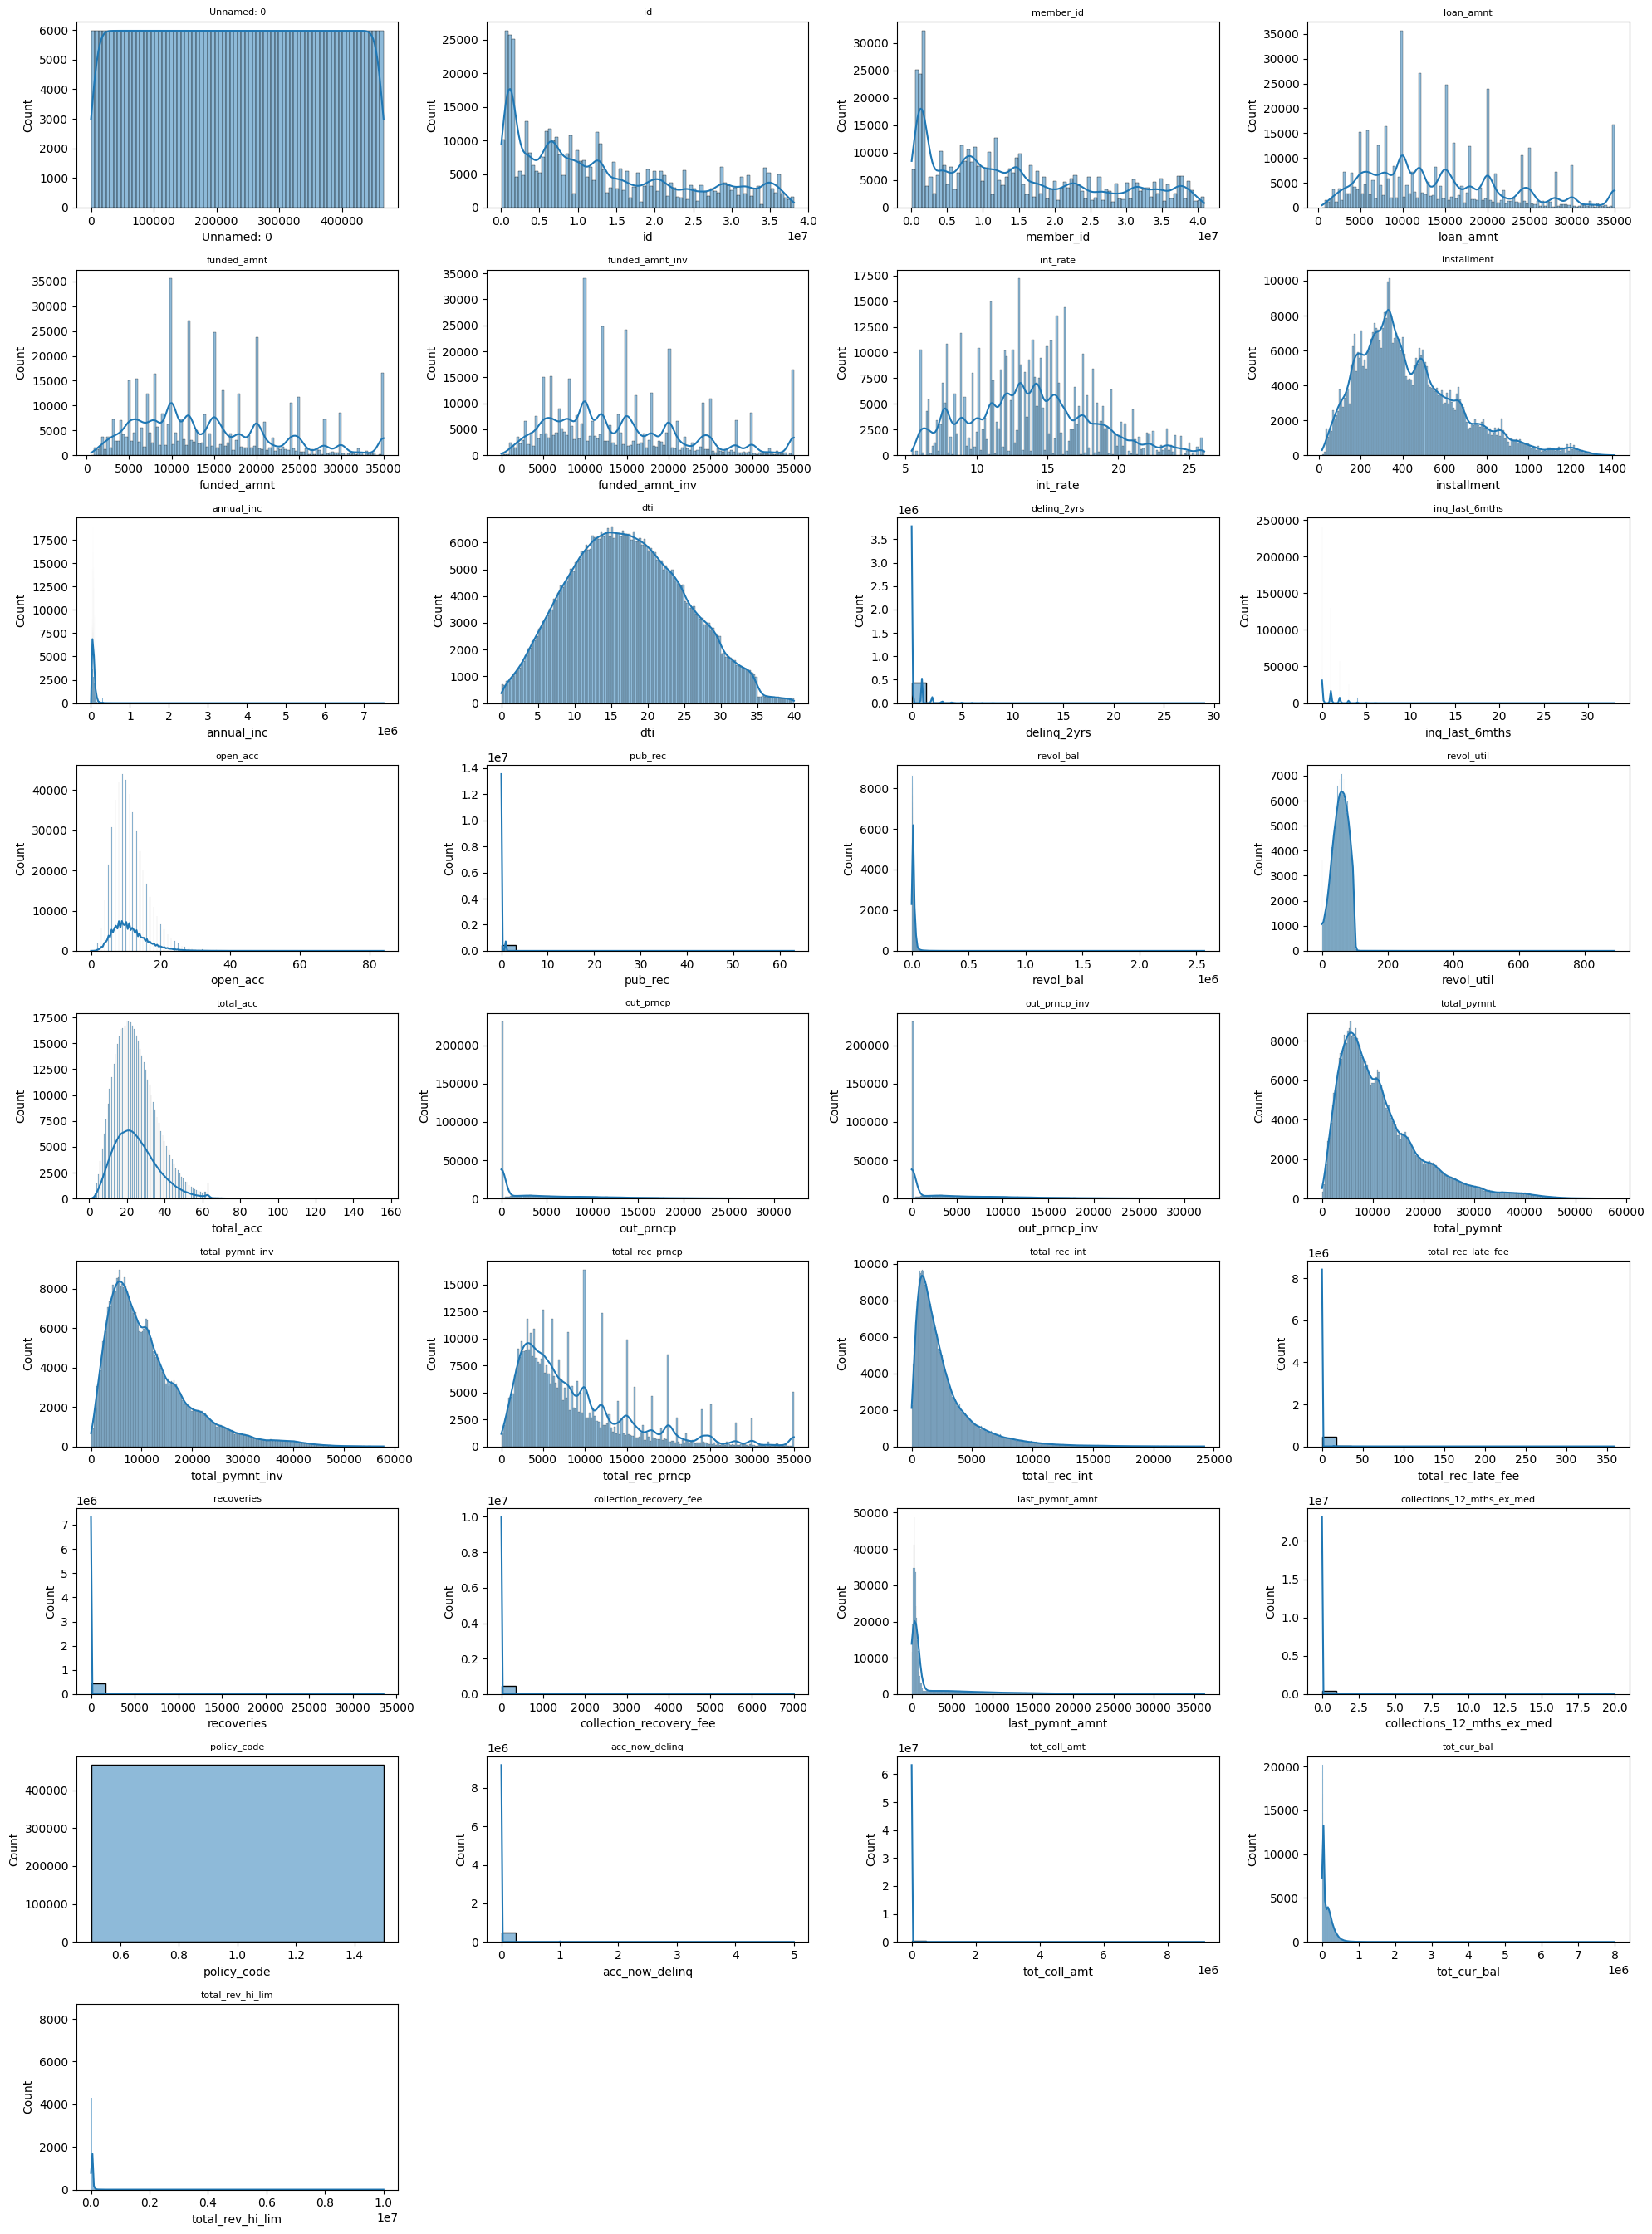

In [156]:
#@title Data Distribution of Numerical Feature
# Ambil semua kolom numerik
num = df.select_dtypes(include=[np.number]).columns

cols = 4
rows = math.ceil(len(num) / cols)

plt.figure(figsize=(cols * 5, rows * 3))

for i in range(len(num)):
    plt.subplot(rows, cols, i + 1)
    sns.histplot(df[num[i]], kde=True)
    plt.title(num[i], fontsize=8)

plt.tight_layout()
plt.show()

**1. Distribusi Umum Fitur**

- Secara keseluruhan, **sebagian besar fitur tidak berdistribusi normal (tidak berbentuk lonceng sempurna)**.
- Distribusi data didominasi oleh:
  - **Right skew (kemencengan ke kanan)** → ekor panjang ke nilai besar
  - **Multimodal** → memiliki lebih dari satu puncak
- Hanya sedikit fitur yang mendekati distribusi normal.

---

**2. Fitur dengan Distribusi Mendekati Normal**

- **`dti` (Debt-to-Income Ratio)**:
  - Memiliki bentuk distribusi yang cukup simetris (mendekati normal).
  - Mayoritas nilai berada di kisaran tengah (±10–25).
  👉 Menunjukkan sebagian besar borrower memiliki rasio utang yang moderat.

---

**3. Fitur dengan Distribusi Right Skew (Dominan)**

Fitur berikut menunjukkan kemencengan ke kanan (banyak nilai kecil, sedikit nilai besar ekstrem):

- **`annual_inc`**
- **`installment`**
- **`revol_bal`**
- **`total_pymnt`**
- **`total_rec_prncp`**
- **`total_rec_int`**
- **`last_pymnt_amnt`**
- **`tot_cur_bal`**
- **`total_rev_hi_lim`**

👉 Insight:
- Banyak borrower berada pada nilai rendah–menengah
- Terdapat **outlier besar (high-value borrowers)**
- Perlu:
  - Log transformation
  - Outlier handling

---

**4. Fitur dengan Distribusi Multimodal**

Fitur yang memiliki lebih dari satu puncak:

- **`loan_amnt`**
- **`funded_amnt`**
- **`funded_amnt_inv`**
- **`int_rate`**

👉 Insight:
- Menunjukkan adanya **segmentasi borrower**
  - Misalnya:
    - Pinjaman kecil vs besar
    - Bunga rendah vs tinggi
- Cocok untuk:
  - Clustering
  - Segmentasi risiko

---

**5. Fitur dengan Nilai Dominan Nol / Sangat Skewed Ekstrem**

Fitur berikut sangat terkonsentrasi di nilai 0:

- **`delinq_2yrs`**
- **`inq_last_6mths`**
- **`pub_rec`**
- **`collections_12_mths_ex_med`**
- **`acc_now_delinq`**
- **`recoveries`**
- **`collection_recovery_fee`**

👉 Insight:
- Mayoritas borrower:
  - Tidak memiliki keterlambatan
  - Tidak memiliki catatan kredit buruk
- Namun:
  - Nilai non-zero → sangat penting (indikator risiko tinggi)

---

**6. Fitur dengan Distribusi Diskrit / Count-Based**

- **`open_acc`**
- **`total_acc`**
- **`inq_last_6mths`**

👉 Insight:
- Berupa data hitungan (integer)
- Distribusi condong ke nilai kecil
- Umum dalam data kredit

---

**7. Fitur Non-Informative**

- **`Unnamed: 0`**:
  - Distribusi seragam (uniform)
  - Hanya nomor urut
  👉 Tidak memiliki makna analitis

- **`id` dan `member_id`**:
  - Pola acak
  👉 Tidak relevan untuk modeling

---

**8. Kesimpulan Umum**

- Tidak ada fitur yang benar-benar berdistribusi normal secara sempurna
- Mayoritas fitur menunjukkan:
  - **Right skew**
  - **Outlier signifikan**
- Beberapa fitur menunjukkan:
  - **Multimodal distribution** → indikasi segmentasi data
- Banyak fitur memiliki:
  - Nilai nol dominan → tetapi tetap penting secara bisnis


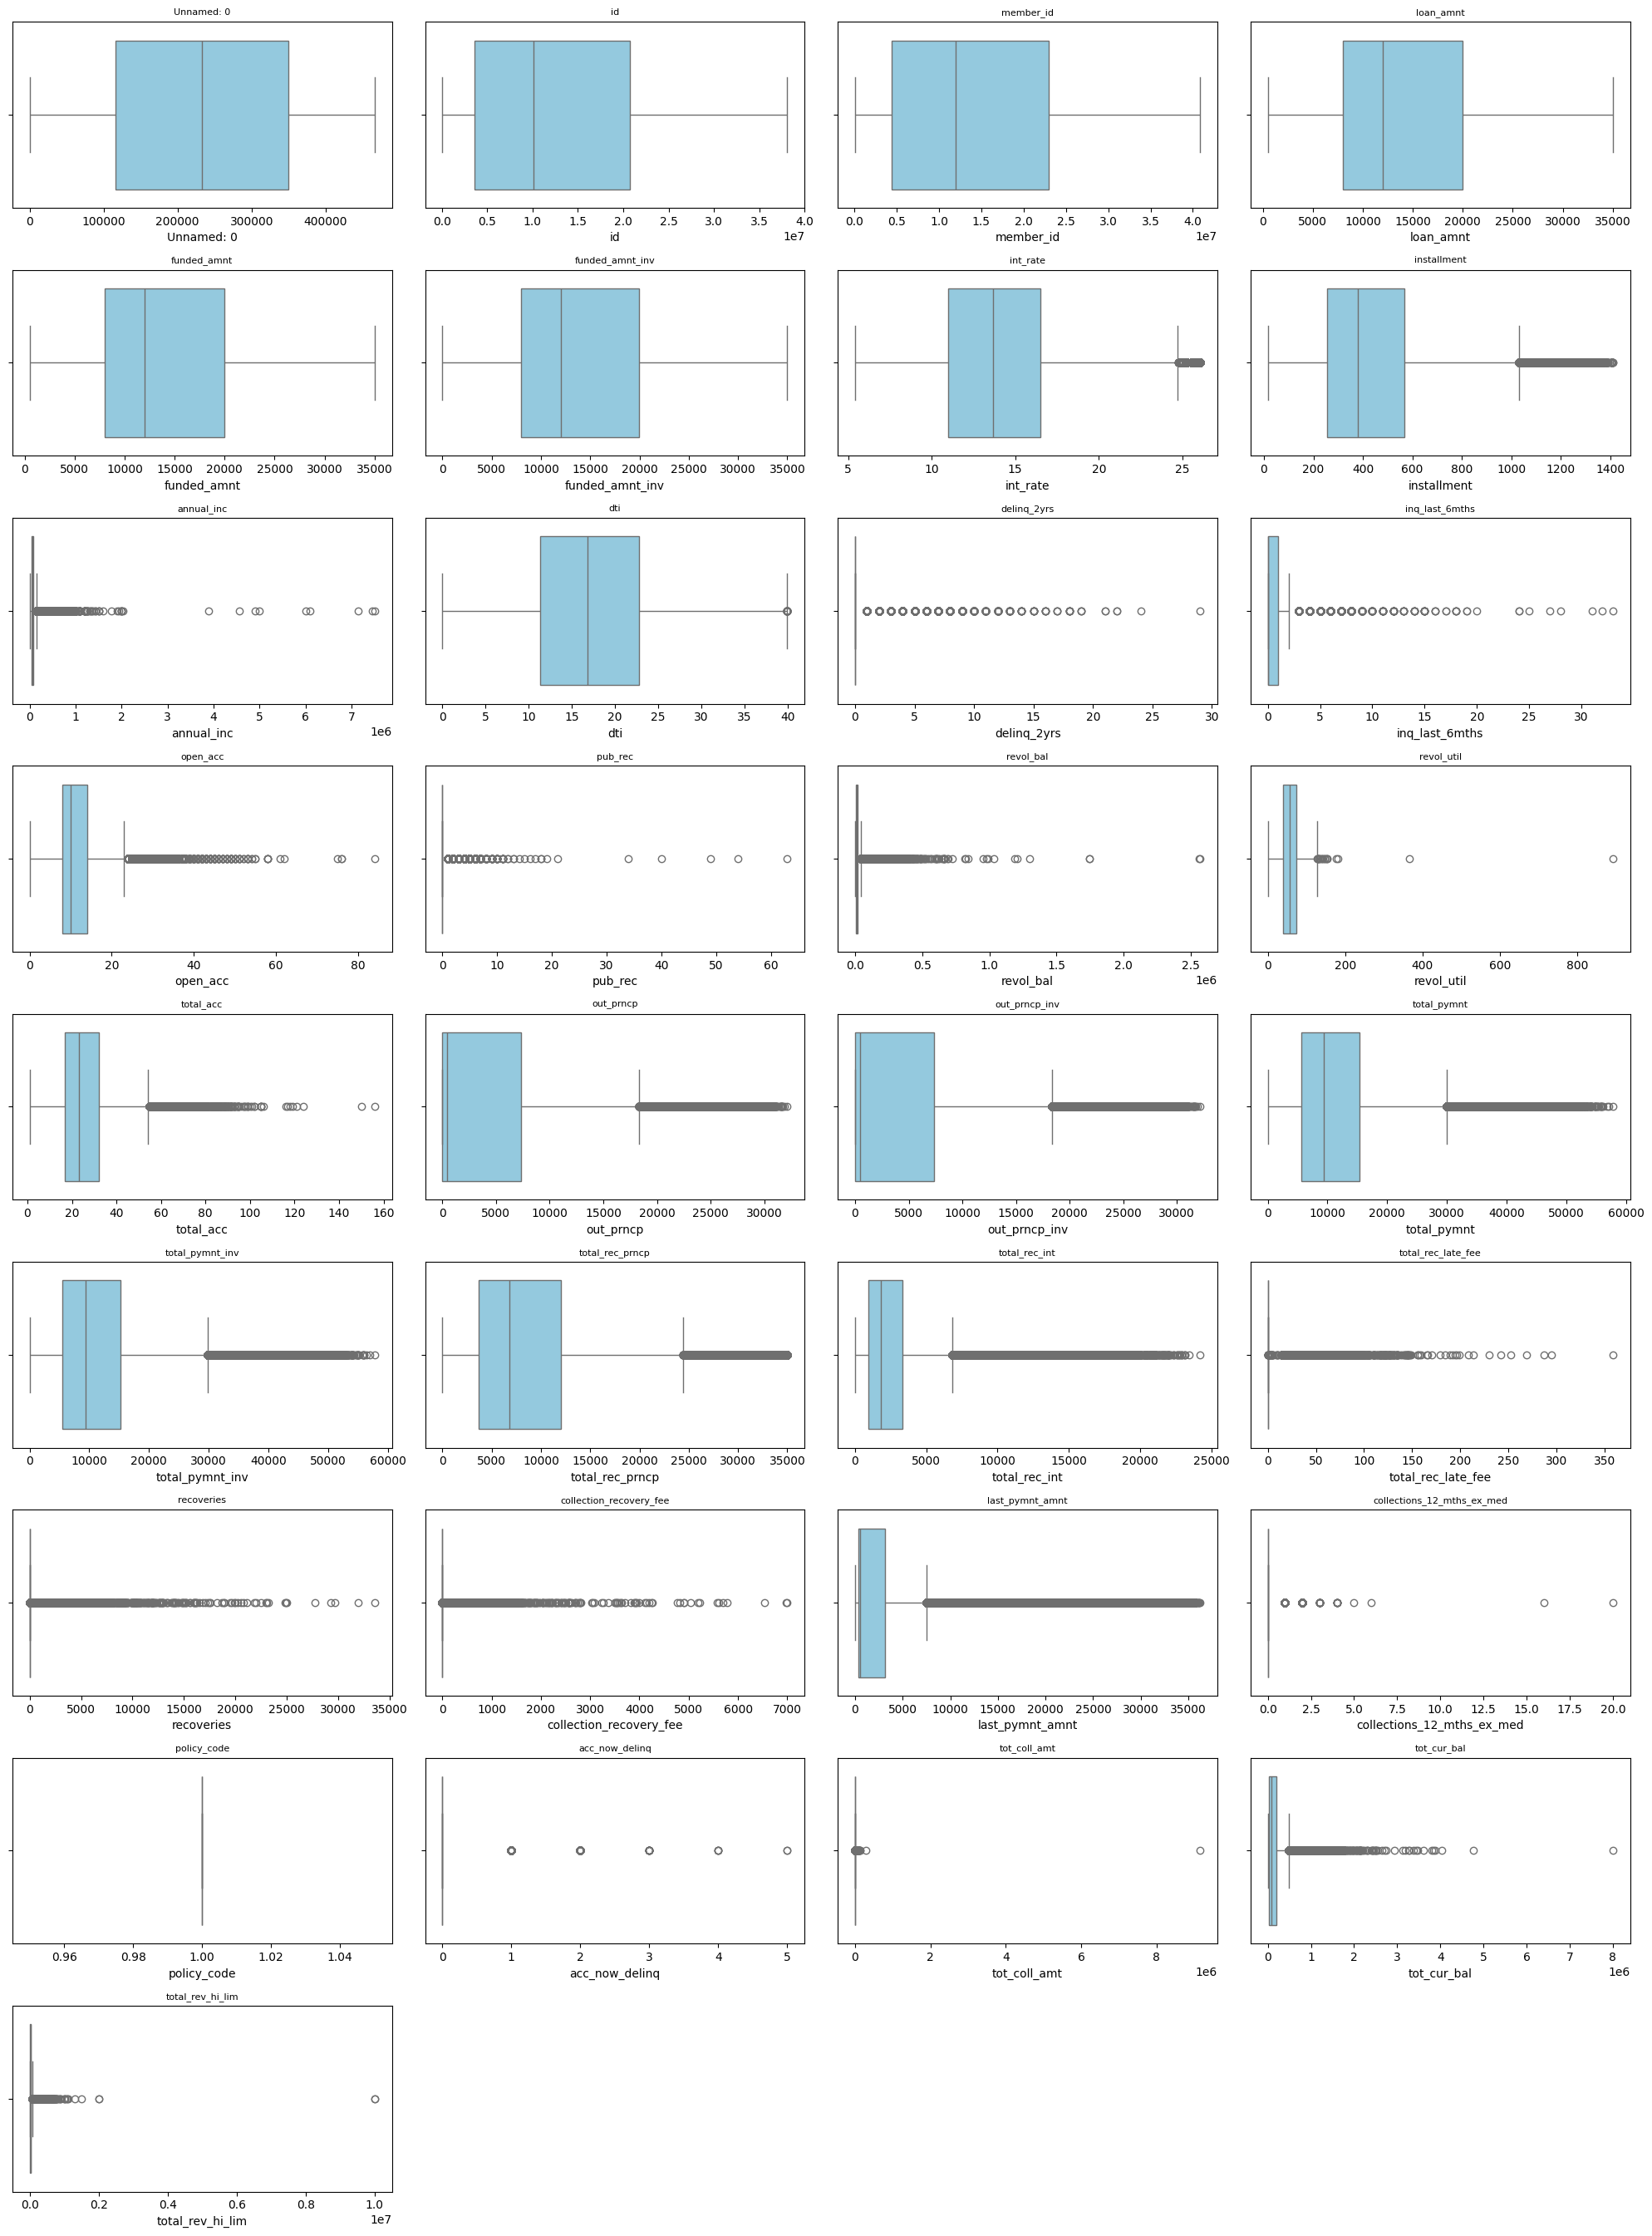

In [157]:
# Tentukan jumlah kolom subplot (bebas)

cols = 4
rows = math.ceil(len(num) / cols)

plt.figure(figsize=(cols * 5, rows * 3))

for i in range(len(num)):
    plt.subplot(rows, cols, i + 1)
    sns.boxplot(x=df[num[i]], color='skyblue')
    plt.title(num[i], fontsize=8)

plt.tight_layout()
plt.show()

Berdasarkan hasil visualisasi menggunakan boxplot, terlihat bahwa **hampir seluruh fitur numerik memiliki outliers**, terutama pada fitur dengan distribusi yang cenderung *right skew* seperti `annual_inc`, `revol_bal`, `total_pymnt`, `total_rec_prncp`, `recoveries`, dan `tot_cur_bal`. Outliers ini ditunjukkan oleh banyaknya titik yang berada di luar whisker (batas IQR), yang mengindikasikan adanya nilai ekstrem dalam dataset.

Dikarenakan adanya outliers pada data, maka kolom-kolom tersebut akan disimpan dalam suatu variabel untuk kemudian dilakukan proses penanganan outliers (seperti trimming atau transformasi). Namun, jika ditinjau lebih dalam, terdapat beberapa kolom seperti `delinq_2yrs`, `inq_last_6mths`, `pub_rec`, `collections_12_mths_ex_med`, dan `acc_now_delinq` yang memiliki **nilai dominan 0**. Pada kolom-kolom ini, kemunculan nilai selain 0 justru merupakan informasi penting yang mencerminkan kondisi risiko kredit peminjam.

Jika pada kolom-kolom dengan dominasi nilai 0 tersebut dilakukan penghapusan outliers, maka **variasi data akan hilang** dan informasi penting terkait perilaku risiko kredit bisa ikut terhapus. Oleh karena itu, meskipun secara visual terdapat banyak outliers, kolom-kolom ini sebaiknya tetap dipertahankan tanpa dilakukan pembersihan outliers secara agresif.

Selain itu, beberapa kolom seperti `id`, `member_id`, dan `Unnamed: 0` tidak memiliki makna analitis karena hanya berupa identifier atau nomor urut data. Kolom-kolom ini tidak relevan untuk analisis lebih lanjut maupun modeling, sehingga tidak perlu dilakukan penanganan outliers dan dapat dipertimbangkan untuk dihapus pada tahap preprocessing.

Di sisi lain, fitur-fitur utama seperti `loan_amnt`, `int_rate`, `installment`, `dti`, serta fitur terkait performa pembayaran seperti `total_pymnt` dan `total_rec_prncp` tetap perlu dipertahankan keasliannya. Oleh karena itu, penanganan outliers pada kolom-kolom ini harus dilakukan secara hati-hati agar tidak menghilangkan karakteristik asli data.

Secara keseluruhan, meskipun banyak fitur menunjukkan adanya outliers, pendekatan yang akan digunakan adalah **tidak langsung menghapus seluruh outliers**, melainkan melakukan seleksi berdasarkan karakteristik masing-masing fitur, sehingga keseimbangan antara kualitas data dan informasi yang terkandung tetap terjaga.

In [158]:
# Categorical (awal)
cat =  df.select_dtypes(exclude=[np.number])
cat.head()

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,last_credit_pull_d,application_type
0,36 months,B,B2,NaN,10+ years,RENT,Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,credit_card,Computer,860xx,AZ,Jan-85,f,Jan-15,Jan-16,INDIVIDUAL
1,60 months,C,C4,Ryder,< 1 year,RENT,Source Verified,Dec-11,Charged Off,n,https://www.lendingclub.com/browse/loanDetail....,car,bike,309xx,GA,Apr-99,f,Apr-13,Sep-13,INDIVIDUAL
2,36 months,C,C5,NaN,10+ years,RENT,Not Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,small_business,real estate business,606xx,IL,Nov-01,f,Jun-14,Jan-16,INDIVIDUAL
3,36 months,C,C1,AIR RESOURCES BOARD,10+ years,RENT,Source Verified,Dec-11,Fully Paid,n,https://www.lendingclub.com/browse/loanDetail....,other,personel,917xx,CA,Feb-96,f,Jan-15,Jan-15,INDIVIDUAL
4,60 months,B,B5,University Medical Group,1 year,RENT,Source Verified,Dec-11,Current,n,https://www.lendingclub.com/browse/loanDetail....,other,Personal,972xx,OR,Jan-96,f,Jan-16,Jan-16,INDIVIDUAL


In [159]:
cat.describe()

,term,grade,sub_grade,emp_title,emp_length,home_ownership,verification_status,issue_d,loan_status,pymnt_plan,url,purpose,title,zip_code,addr_state,earliest_cr_line,initial_list_status,last_pymnt_d,last_credit_pull_d,application_type
count,466285,466285,466285,438697,445277,466285,466285,466285,466285,466285,466285,466285,466264,466285,466285,466256,466285,465909,466243,466285
unique,2,7,35,205475,11,6,3,91,9,2,466285,14,63098,888,50,664,2,98,103,1
top,36 months,B,B3,Teacher,10+ years,MORTGAGE,Verified,Oct-14,Current,n,https://www.lendingclub.com/browse/loanDetail....,debt_consolidation,Debt consolidation,945xx,CA,Oct-00,f,Jan-16,Jan-16,INDIVIDUAL
freq,337953,136929,31686,5399,150049,235875,168055,38782,224226,466276,1,274195,164075,5304,71450,3674,303005,179620,327699,466285


In [160]:
#@title Counting Values of Categorical Features
for column in cat.columns:
    count_values = cat[column].value_counts()
    print(f"Column: {column}")
    print(f"Count of Values:\n{count_values}\n")

Column: term
Count of Values:
term
36 months    337953
60 months    128332
Name: count, dtype: int64

Column: grade
Count of Values:
grade
B    136929
C    125293
D     76888
A     74867
E     35757
F     13229
G      3322
Name: count, dtype: int64

Column: sub_grade
Count of Values:
sub_grade
B3    31686
B4    30505
C1    26953
C2    26740
B2    26610
C3    25317
B5    25252
C4    24105
B1    22876
C5    22178
A5    21757
D1    19261
A4    19045
D2    17046
D3    14916
D4    14099
A3    12568
D5    11566
A2    10956
A1    10541
E1     9033
E2     8669
E3     6976
E4     5992
E5     5087
F1     3940
F2     3001
F3     2708
F4     2067
F5     1513
G1     1109
G2      823
G3      583
G4      422
G5      385
Name: count, dtype: int64

Column: emp_title
Count of Values:
emp_title
Teacher                              5399
Manager                              4438
Registered Nurse                     2316
RN                                   2204
Supervisor                           1967
   

In [161]:
#@title Convert Categorical to Datetime
date_cols = [
    'issue_d',
    'earliest_cr_line',
    'last_pymnt_d',
    'last_credit_pull_d'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col], format='%b-%y')

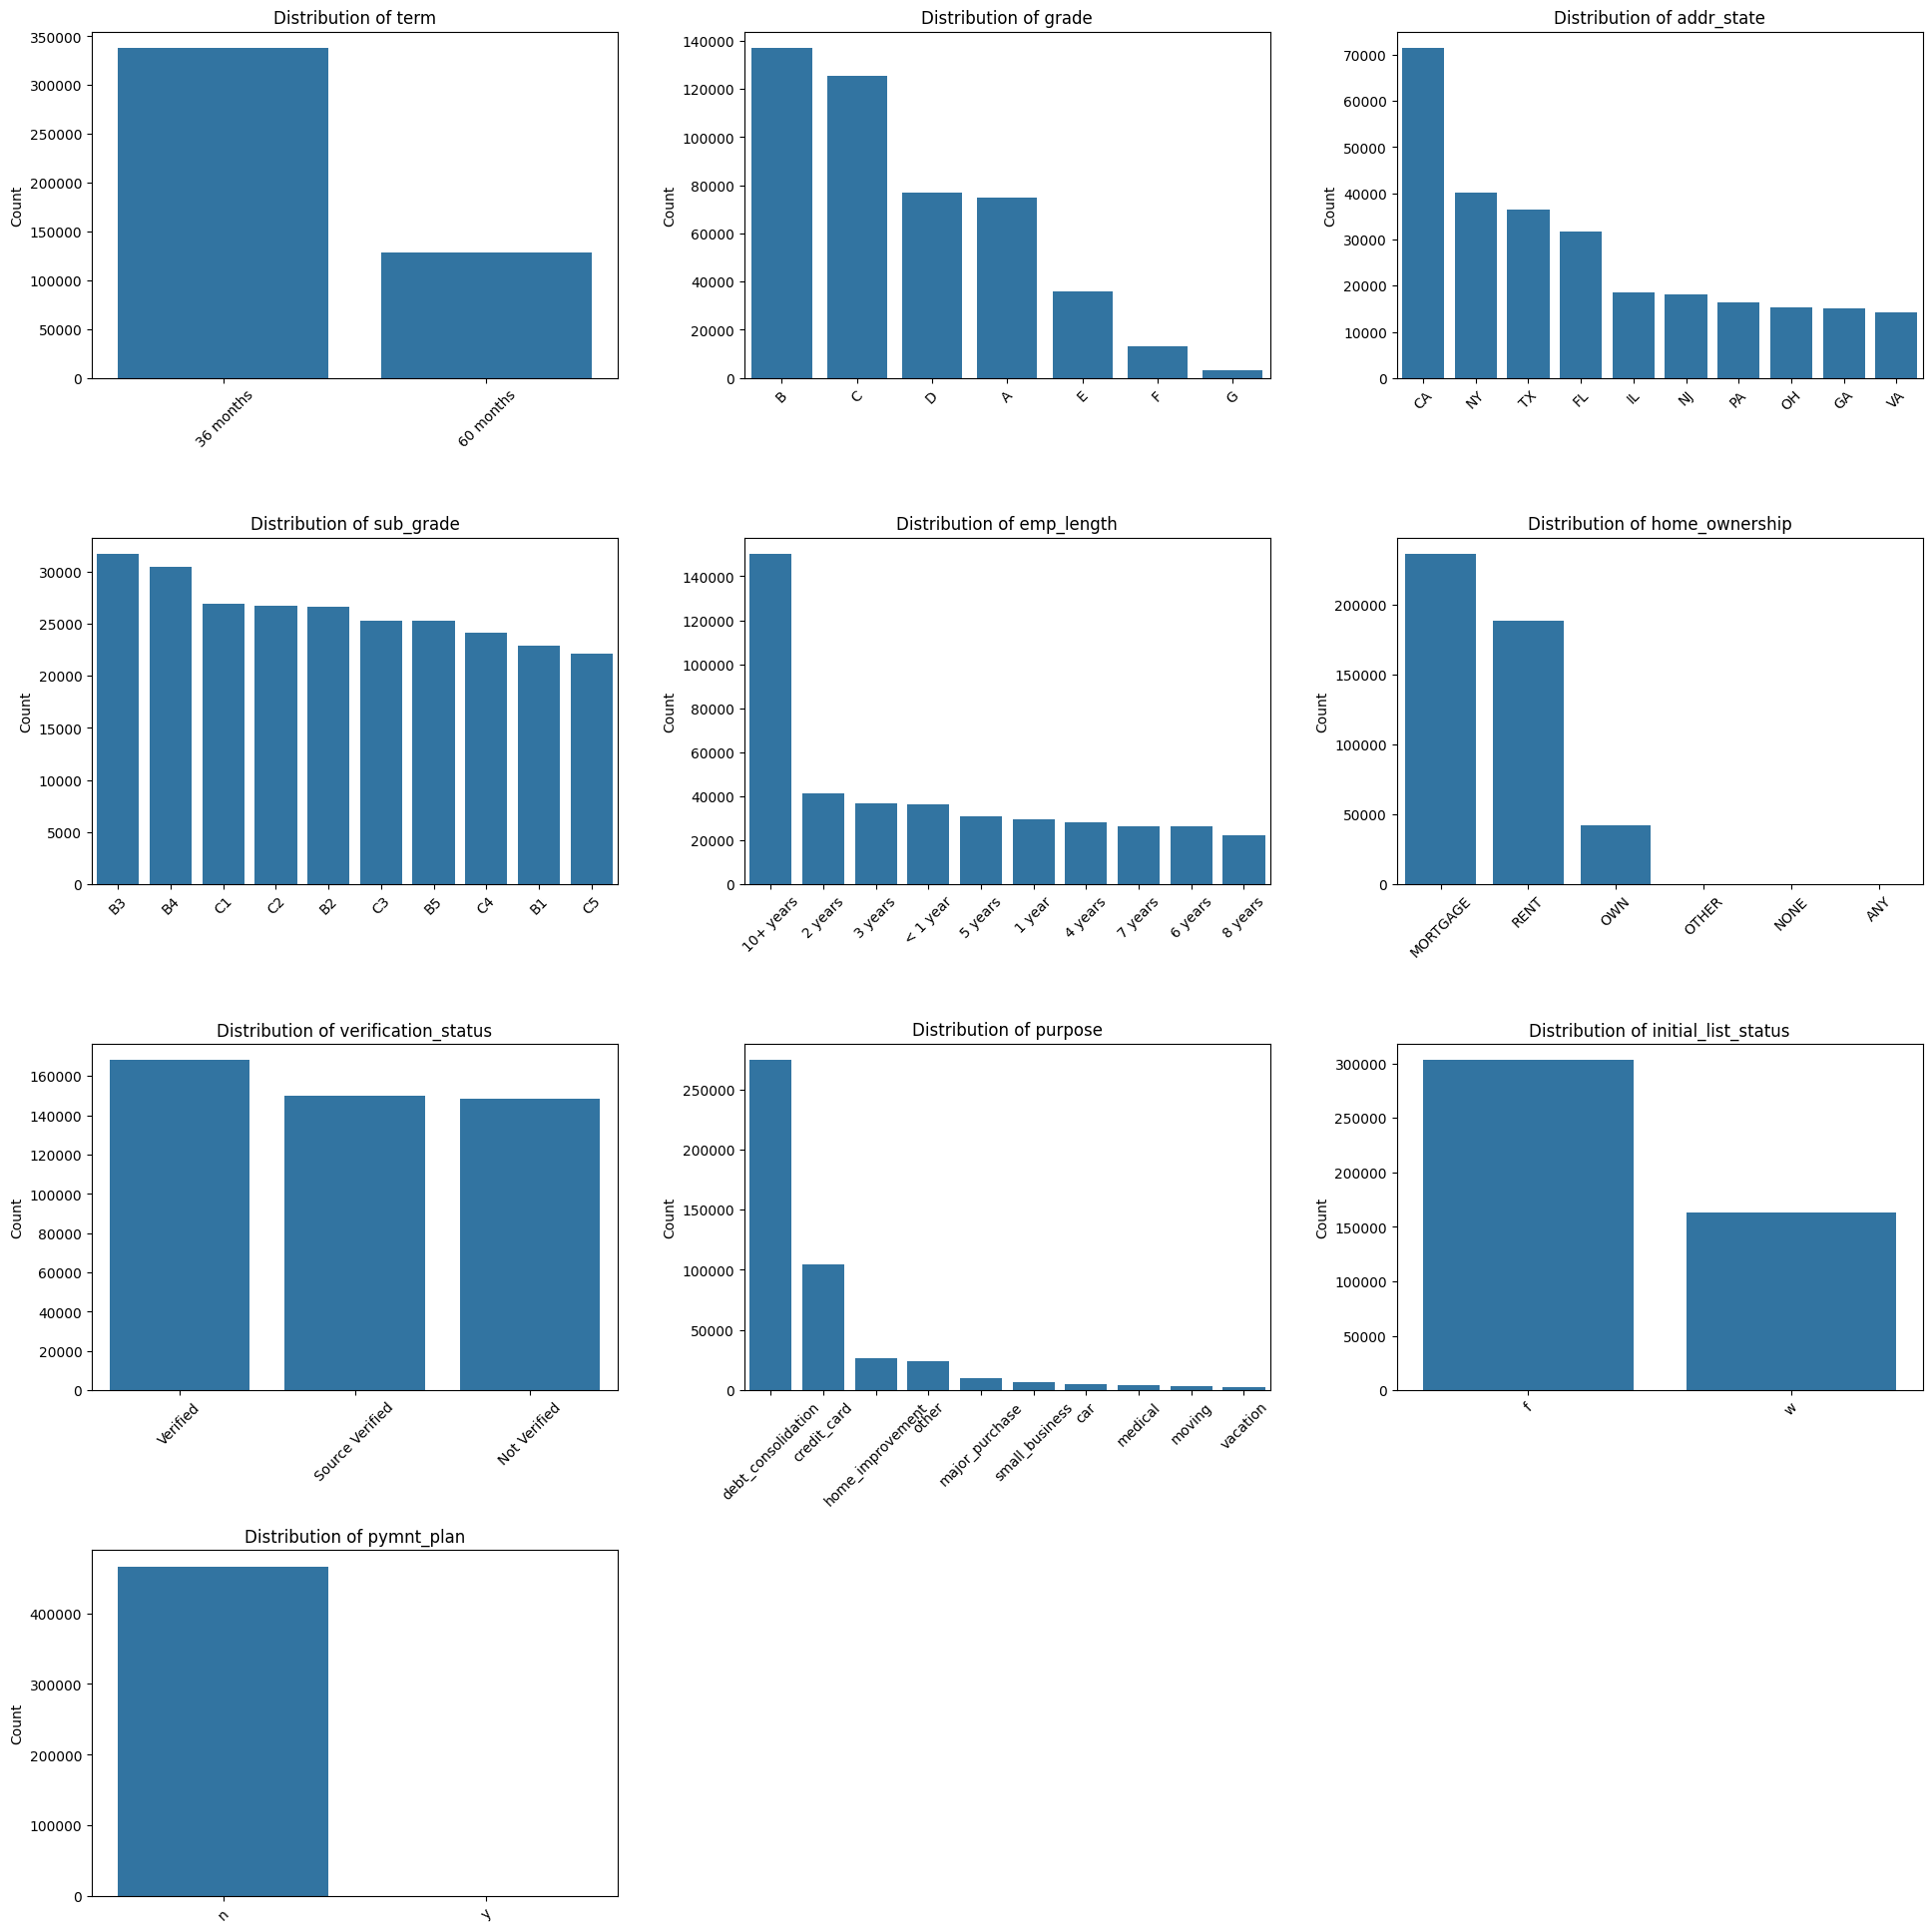

In [ ]:
#@title Categorical Data Distribution 
cols = [
    'term',
    'grade',
    'addr_state',
    'sub_grade',
    'emp_length',
    'home_ownership',
    'verification_status',
    'purpose',
    'initial_list_status',
    'pymnt_plan'
]

n_cols = 3
n_rows = math.ceil(len(cols) / n_cols)

plt.figure(figsize=(20, n_rows * 5))

for i, col in enumerate(cols):
    plt.subplot(n_rows, n_cols, i+1)

    # ambil top 10 untuk kolom dengan banyak kategori
    order = df[col].value_counts().index[:10]

    sns.countplot(data=df, x=col, order=order)

    plt.title(f'Distribution of {col}')
    plt.xlabel('')
    plt.ylabel('Count')
    plt.xticks(rotation=45)

plt.tight_layout(pad=3)
plt.show()


## DATA CLEANING

In [163]:
cols_to_drop = ['id', 'member_id', 'Unnamed: 0', 'policy_code', 'emp_title', 'issue_d', 'url', 'title', 'zip_code', 'earliest_cr_line', 'last_pymnt_d',  'last_credit_pull_d', 'application_type' ]
df = df.drop(columns=cols_to_drop)

Pada tahap ini dilakukan proses seleksi fitur dengan cara menghapus beberapa kolom yang dianggap tidak relevan atau tidak memberikan kontribusi signifikan terhadap proses pemodelan.

Kolom-kolom yang dihapus umumnya berupa:

- Identifier unik seperti ID, yang tidak memiliki nilai prediktif
- Informasi teks bebas seperti judul atau deskripsi, yang sulit diolah tanpa teknik lanjutan
- Data berbentuk tanggal
- Informasi redundan atau tidak konsisten

Penghapusan fitur ini bertujuan untuk:

- Mengurangi kompleksitas dataset
- Meningkatkan efisiensi proses pelatihan model
- Menghindari noise yang dapat menurunkan performa model
- Meminimalisir risiko overfitting

Dengan mengeliminasi fitur yang tidak relevan, dataset menjadi lebih terfokus pada variabel-variabel yang действительно berpengaruh terhadap prediksi.

In [164]:
df.head()

,loan_amnt,funded_amnt,funded_amnt_inv,term,int_rate,installment,grade,sub_grade,emp_length,home_ownership,annual_inc,verification_status,loan_status,pymnt_plan,purpose,addr_state,dti,delinq_2yrs,inq_last_6mths,open_acc,pub_rec,revol_bal,revol_util,total_acc,initial_list_status,out_prncp,out_prncp_inv,total_pymnt,total_pymnt_inv,total_rec_prncp,total_rec_int,total_rec_late_fee,recoveries,collection_recovery_fee,last_pymnt_amnt,collections_12_mths_ex_med,acc_now_delinq,tot_coll_amt,tot_cur_bal,total_rev_hi_lim
0,5000,5000,4975.0,36 months,10.65,162.87,B,B2,10+ years,RENT,24000.0,Verified,Fully Paid,n,credit_card,AZ,27.65,0.0,1.0,3.0,0.0,13648,83.7,9.0,f,0.0,0.0,5861.071414,5831.78,5000.00,861.07,0.00,0.00,0.00,171.62,0.0,0.0,NaN,NaN,NaN
1,2500,2500,2500.0,60 months,15.27,59.83,C,C4,< 1 year,RENT,30000.0,Source Verified,Charged Off,n,car,GA,1.00,0.0,5.0,3.0,0.0,1687,9.4,4.0,f,0.0,0.0,1008.710000,1008.71,456.46,435.17,0.00,117.08,1.11,119.66,0.0,0.0,NaN,NaN,NaN
2,2400,2400,2400.0,36 months,15.96,84.33,C,C5,10+ years,RENT,12252.0,Not Verified,Fully Paid,n,small_business,IL,8.72,0.0,2.0,2.0,0.0,2956,98.5,10.0,f,0.0,0.0,3003.653644,3003.65,2400.00,603.65,0.00,0.00,0.00,649.91,0.0,0.0,NaN,NaN,NaN
3,10000,10000,10000.0,36 months,13.49,339.31,C,C1,10+ years,RENT,49200.0,Source Verified,Fully Paid,n,other,CA,20.00,0.0,1.0,10.0,0.0,5598,21.0,37.0,f,0.0,0.0,12226.302210,12226.30,10000.00,2209.33,16.97,0.00,0.00,357.48,0.0,0.0,NaN,NaN,NaN
4,3000,3000,3000.0,60 months,12.69,67.79,B,B5,1 year,RENT,80000.0,Source Verified,Current,n,other,OR,17.94,0.0,0.0,15.0,0.0,27783,53.9,38.0,f,766.9,766.9,3242.170000,3242.17,2233.10,1009.07,0.00,0.00,0.00,67.79,0.0,0.0,NaN,NaN,NaN


In [165]:
def check_missing_data(df):
    null_counts = df.isnull().sum()
    null_percentages = (df.isnull().sum() / len(df)) * 100
    missing_data = pd.concat([null_counts, null_percentages], axis=1, keys=['Total Null', 'Persentase (%)'])
    missing_data = missing_data[missing_data['Total Null'] > 0].sort_values(by='Total Null', ascending=False)

    return missing_data

# Cara pakai:
print(check_missing_data(df))

                            Total Null  Persentase (%)
tot_coll_amt                     70276       15.071469
tot_cur_bal                      70276       15.071469
total_rev_hi_lim                 70276       15.071469
emp_length                       21008        4.505399
revol_util                         340        0.072917
collections_12_mths_ex_med         145        0.031097
delinq_2yrs                         29        0.006219
inq_last_6mths                      29        0.006219
open_acc                            29        0.006219
pub_rec                             29        0.006219
total_acc                           29        0.006219
acc_now_delinq                      29        0.006219
annual_inc                           4        0.000858


Kolom dengan jumlah missing value terbesar adalah tot_coll_amt, tot_cur_bal, dan total_rev_hi_lim, masing-masing memiliki sekitar 15% data hilang. Persentase ini tergolong cukup signifikan sehingga memerlukan penanganan khusus agar tidak mempengaruhi kualitas model.

Selanjutnya, kolom emp_length memiliki missing value sekitar 4,5%, yang masih tergolong moderat dan dapat ditangani tanpa menghapus data.

Sementara itu, beberapa kolom lain seperti revol_util, collections_12_mths_ex_med, serta variabel terkait riwayat kredit (misalnya jumlah keterlambatan atau akun) memiliki missing value dalam jumlah yang sangat kecil (kurang dari 1%). Bahkan, beberapa kolom hanya memiliki missing value di bawah 0,01%, sehingga dampaknya terhadap analisis relatif minimal.

Kolom annual_inc memiliki missing value paling sedikit, yaitu hampir mendekati nol, sehingga tidak menjadi perhatian utama dalam proses pembersihan data.

In [166]:
# Copy dataset biar aman
df_imputed = df.copy()

# 1. NUMERICAL (Median)
num_median_cols = [
    'tot_cur_bal',
    'total_rev_hi_lim',
    'tot_coll_amt',
    'revol_util',
    'annual_inc'
]

for col in num_median_cols:
    df_imputed[col].fillna(df_imputed[col].median(), inplace=True)

# 2. DISCRETE
count_cols = [
    'collections_12_mths_ex_med',
    'open_acc',
    'inq_last_6mths',
    'delinq_2yrs',
    'total_acc',
    'pub_rec',
    'acc_now_delinq'
]

for col in count_cols:
    df_imputed[col].fillna(0, inplace=True)

# 3. CATEGORICAL (Mode)
df_imputed['emp_length'].fillna(df_imputed['emp_length'].mode()[0], inplace=True)

# CHECK
print(check_missing_data(df_imputed))

C:\Users\HP\AppData\Local\Temp\ipykernel_22804\676548309.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df_imputed[col].fillna(df_imputed[col].median(), inplace=True)
C:\Users\HP\AppData\Local\Temp\ipykernel_22804\676548309.py:14: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.


Empty DataFrame
Columns: [Total Null, Persentase (%)]
Index: []


Pada tahap ini dilakukan proses penanganan nilai yang hilang (missing values) dengan tujuan agar dataset menjadi lebih bersih dan siap digunakan dalam pemodelan.

Proses diawali dengan membuat salinan dataset untuk menjaga data asli tetap aman. Selanjutnya, imputasi dilakukan berdasarkan jenis data pada masing-masing kolom.

Untuk data numerik, nilai yang hilang diisi menggunakan median. Pendekatan ini dipilih karena median lebih stabil dan tidak terpengaruh oleh nilai ekstrem (outlier), sehingga lebih representatif untuk distribusi data yang tidak normal.

Pada data diskrit atau berbentuk hitungan, nilai kosong diisi dengan angka 0. Hal ini didasarkan pada asumsi bahwa tidak adanya data menunjukkan tidak adanya kejadian, seperti tidak ada tunggakan atau tidak ada catatan tertentu.

Sementara itu, untuk data kategorikal, nilai yang hilang diisi menggunakan nilai yang paling sering muncul (mode). Metode ini digunakan untuk mempertahankan distribusi kategori dalam dataset tanpa menimbulkan bias yang signifikan.

Setelah seluruh proses imputasi dilakukan, dilakukan pengecekan ulang untuk memastikan bahwa tidak terdapat lagi missing value dalam dataset.

In [167]:
bad_loan = [
    'Charged Off',
    'Late (31-120 days)',
    'Late (16-30 days)',
    'In Grace Period',
    'Does not meet the credit policy. Status:Charged Off'
]

df_imputed['loan_category'] = df_imputed['loan_status'].isin(bad_loan).map({
    True: 'BAD LOAN',
    False: 'GOOD LOAN'
})

df_imputed['loan_category_binary'] = df_imputed['loan_category'].map({
    'GOOD LOAN': 0,
    'BAD LOAN': 1
})

# cek
print(df_imputed['loan_category'].value_counts())

loan_category
GOOD LOAN    411785
BAD LOAN      54500
Name: count, dtype: int64


In [168]:
df_encoded = df_imputed.copy()

# DROP loan_status (penting!)
df_encoded.drop('loan_status', axis=1, inplace=True)

le = LabelEncoder()

cat_cols = df_encoded.select_dtypes(include=['object']).columns

for col in cat_cols:
    df_encoded[col] = le.fit_transform(df_encoded[col].astype(str))

In [169]:
emp_length_map = {
    '< 1 year': 0,
    '1 year': 1,
    '2 years': 2,
    '3 years': 3,
    '4 years': 4,
    '5 years': 5,
    '6 years': 6,
    '7 years': 7,
    '8 years': 8,
    '9 years': 9,
    '10+ years': 10
}

df_encoded['emp_length'] = df_imputed['emp_length'].map(emp_length_map)

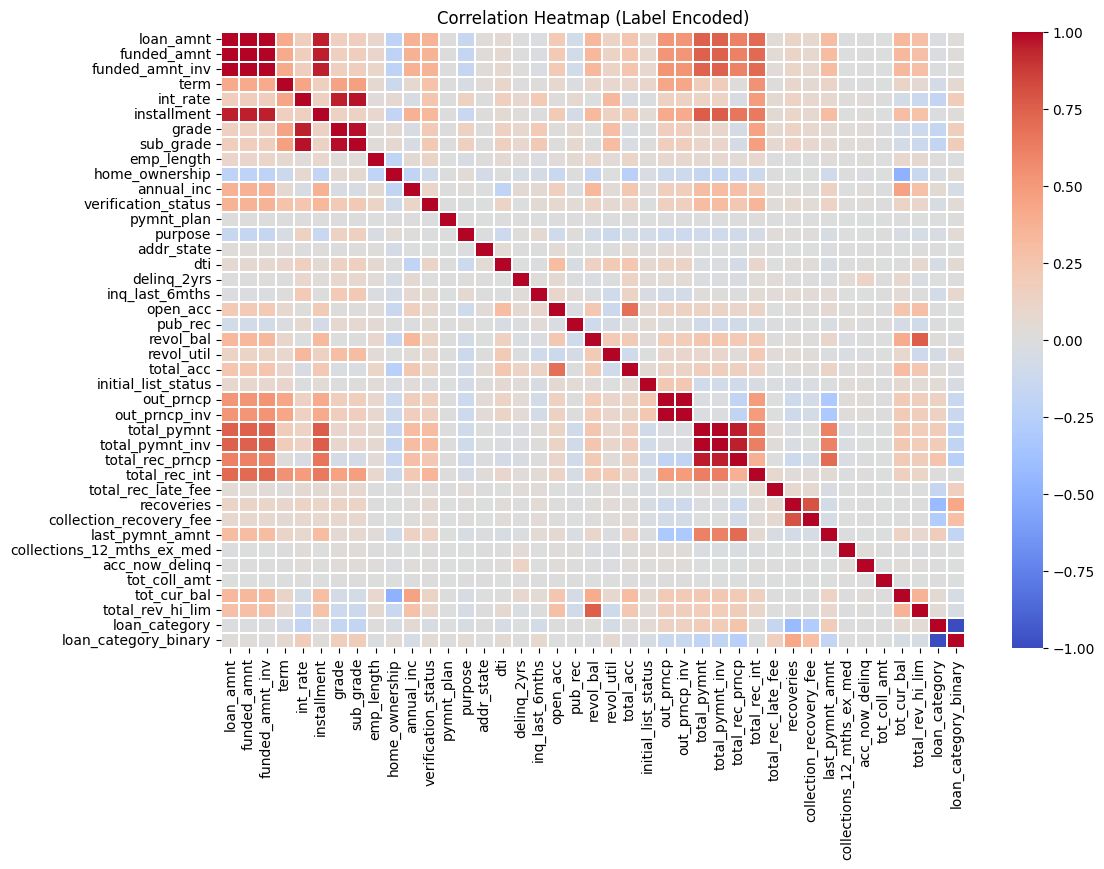

In [170]:
corr_matrix = df_encoded.corr()

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr_matrix,
    cmap='coolwarm',
    linewidths=0.3
)

plt.title('Correlation Heatmap (Label Encoded)')
plt.show()

In [171]:
X = df_encoded.drop(['loan_category', 'loan_category_binary'], axis=1)
y = df_encoded['loan_category_binary']

In [172]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y   # penting kalau data imbalance
)

In [173]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

### 1. Logistic Regression

In [174]:
LR = LogisticRegression(max_iter=1000)
LR.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000)

In [175]:
y_pred_LR = LR.predict(X_test_scaled)
y_proba_LR = LR.predict_proba(X_test_scaled)[:, 1]

In [176]:
print(classification_report(y_test, y_pred_LR))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     82357
           1       0.99      0.78      0.87     10900

    accuracy                           0.97     93257
   macro avg       0.98      0.89      0.93     93257
weighted avg       0.97      0.97      0.97     93257



In [177]:
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_LR))
print("Accuracy Score:", accuracy_score(y_test, y_pred_LR))

ROC AUC Score: 0.96230042443321
Accuracy Score: 0.9736641753434059


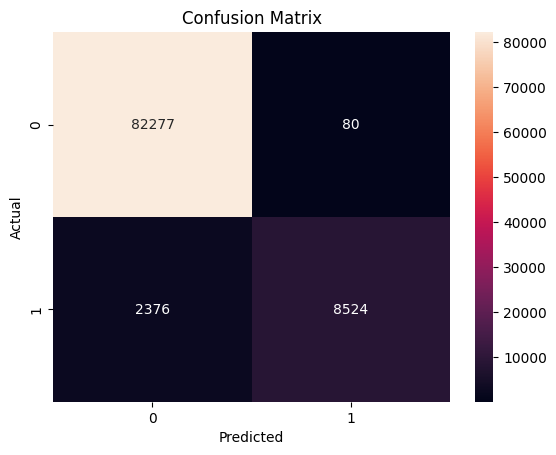

In [178]:
cm = confusion_matrix(y_test, y_pred_LR)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 2.Random Forest

In [179]:
rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train_scaled, y_train)


RandomForestClassifier(random_state=42)

In [180]:
y_pred_rf = rf.predict(X_test_scaled)
y_proba_rf = rf.predict_proba(X_test_scaled)[:, 1]

In [181]:
print(classification_report(y_test, y_pred_rf))

              precision    recall  f1-score   support

           0       0.97      1.00      0.99     82357
           1       0.99      0.80      0.89     10900

    accuracy                           0.98     93257
   macro avg       0.98      0.90      0.94     93257
weighted avg       0.98      0.98      0.97     93257



In [182]:
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_rf))
print("Accuracy Score:", accuracy_score(y_test, y_pred_rf))

ROC AUC Score: 0.9653253005793863
Accuracy Score: 0.9760125245289898


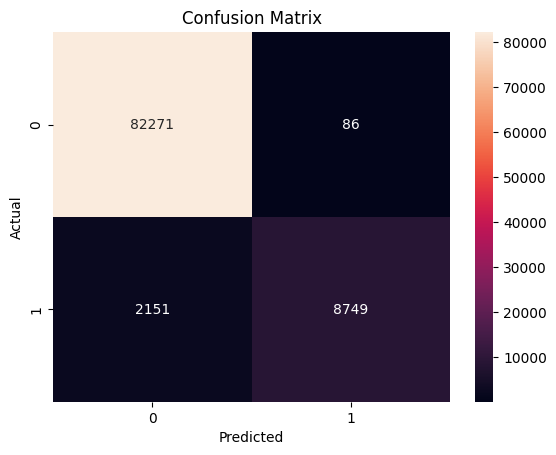

In [183]:
cm = confusion_matrix(y_test, y_pred_rf)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 3. Decision Tree

In [184]:
dt = DecisionTreeClassifier(random_state=42)
dt.fit(X_train_scaled, y_train)

DecisionTreeClassifier(random_state=42)

In [185]:
y_pred_dt = dt.predict(X_test_scaled)
y_proba_dt = dt.predict_proba(X_test_scaled)[:, 1]

In [186]:
print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98     82357
           1       0.80      0.83      0.82     10900

    accuracy                           0.96     93257
   macro avg       0.89      0.90      0.90     93257
weighted avg       0.96      0.96      0.96     93257



In [187]:
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_dt))
print("Accuracy Score:", accuracy_score(y_test, y_pred_dt))

ROC AUC Score: 0.9019275206298647
Accuracy Score: 0.9560569179793474


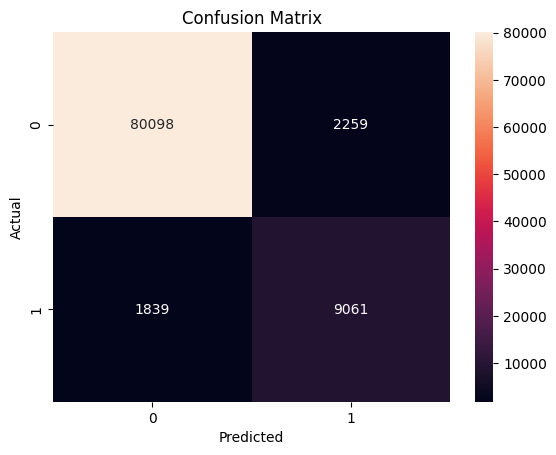

In [188]:
cm = confusion_matrix(y_test, y_pred_dt)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

### 4. K-Nearest Neighbors (KNN)

In [189]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled, y_train)

KNeighborsClassifier()

In [190]:
y_pred_knn = knn.predict(X_test_scaled)
y_proba_knn = knn.predict_proba(X_test_scaled)[:, 1]

In [191]:
print(classification_report(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.94      0.99      0.97     82357
           1       0.93      0.53      0.67     10900

    accuracy                           0.94     93257
   macro avg       0.93      0.76      0.82     93257
weighted avg       0.94      0.94      0.93     93257



In [192]:
print("ROC AUC Score:", roc_auc_score(y_test, y_proba_knn))
print("Accuracy Score:", accuracy_score(y_test, y_pred_knn))

ROC AUC Score: 0.8550159498036797
Accuracy Score: 0.9398436578487406


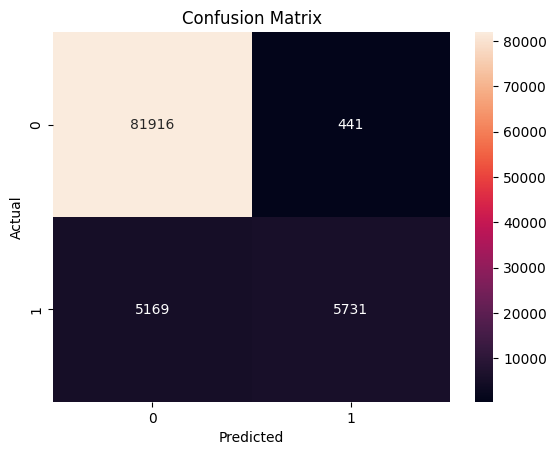

In [193]:
cm = confusion_matrix(y_test, y_pred_knn)

sns.heatmap(cm, annot=True, fmt='d')
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()